# Model Evaluation: A Small Interactive Lab

This notebook shows simple ways to check model predictions.

We use small examples made in this notebook. Change the values in the interactive controls and see what changes.

## Part 1 — Imports

We use NumPy, Matplotlib, scikit-learn, and ipywidgets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
)

plt.style.use("seaborn-v0_8-whitegrid")

## Part 2 — Regression Evaluation

Regression predicts numbers. We compare each predicted number with the actual number.

### Example

The actual values are `10, 20, 30, 40, 50`. The model gives nearby predictions.

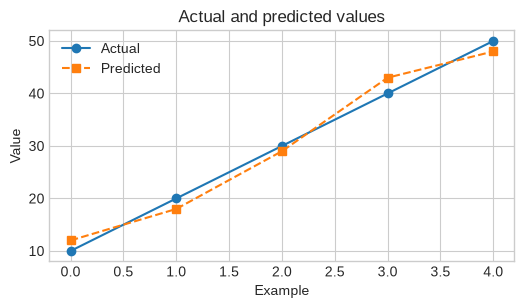

In [2]:
y_actual = [10, 20, 30, 40, 50]
y_predicted = [12, 18, 29, 43, 48]

plt.figure(figsize=(6, 3))
plt.plot(y_actual, "o-", label="Actual")
plt.plot(y_predicted, "s--", label="Predicted")
plt.xlabel("Example")
plt.ylabel("Value")
plt.title("Actual and predicted values")
plt.legend()
plt.show()

### Mean Squared Error (MSE)

MSE is the average of the squared errors. A bigger mistake counts much more.

**Formula:** average of `(actual − predicted)²`. Lower is better.

In [3]:
mse = mean_squared_error(y_actual, y_predicted)
print(f"MSE: {mse:.2f}")

MSE: 4.40


### Mean Absolute Error (MAE)

MAE is the average size of the errors. It uses the same units as the values.

**Formula:** average of `|actual − predicted|`. Lower is better.

In [4]:
mae = mean_absolute_error(y_actual, y_predicted)
print(f"MAE: {mae:.2f}")

MAE: 2.00


### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE. It uses the same units as the values.

**Formula:** `√MSE`. Lower is better.

In [5]:
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
print(f"RMSE: {rmse:.2f}")

RMSE: 2.10


### R² / R-squared

R² compares the model with a simple guess: the average actual value. Closer to 1 is usually better. It can be below 0.

In [6]:
r2 = r2_score(y_actual, y_predicted)
print(f"R²: {r2:.3f}")

R²: 0.978


### Interactive regression

Change any actual or predicted value. All four scores and the chart update.

In [7]:
actual_boxes = [widgets.FloatText(value=v, description=f"Actual {i+1}", layout=widgets.Layout(width="170px")) for i, v in enumerate(y_actual)]
pred_boxes = [widgets.FloatText(value=v, description=f"Predicted {i+1}", layout=widgets.Layout(width="190px")) for i, v in enumerate(y_predicted)]

reg_output = widgets.Output()
def update_regression(change=None):
    actual = np.array([box.value for box in actual_boxes], dtype=float)
    predicted = np.array([box.value for box in pred_boxes], dtype=float)
    with reg_output:
        reg_output.clear_output(wait=True)
        mse_value = mean_squared_error(actual, predicted)
        mae_value = mean_absolute_error(actual, predicted)
        rmse_value = np.sqrt(mse_value)
        r2_value = r2_score(actual, predicted)
        print(f"MSE: {mse_value:.2f}   MAE: {mae_value:.2f}   RMSE: {rmse_value:.2f}   R²: {r2_value:.3f}")
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.plot(actual, "o-", label="Actual")
        ax.plot(predicted, "s--", label="Predicted")
        ax.set(xlabel="Example", ylabel="Value", title="Updated regression example")
        ax.legend()
        plt.show()

for box in actual_boxes + pred_boxes:
    box.observe(update_regression, names="value")
display(widgets.VBox([widgets.HBox(actual_boxes[:3]), widgets.HBox(actual_boxes[3:]),
                      widgets.HBox(pred_boxes[:3]), widgets.HBox(pred_boxes[3:]), reg_output]))
update_regression()

## Part 3 — Classification Evaluation

Classification predicts a label, such as `0` or `1`. Here, `1` is the positive class.

### Three kinds of values

- **Actual values** are the right answers.
- **Predicted labels** are the model's class choices: `0` or `1`.
- **Predicted probabilities** are the model's scores for class `1`, from 0 to 1. A cutoff turns a score into a label.

### Small example and confusion matrix

The confusion matrix counts correct and wrong labels. Rows are actual labels; columns are predicted labels. It shows true negatives (TN), false positives (FP), false negatives (FN), and true positives (TP).

Confusion matrix (rows: actual 0, 1; columns: predicted 0, 1):
[[3 1]
 [1 3]]
TN=3, FP=1, FN=1, TP=3


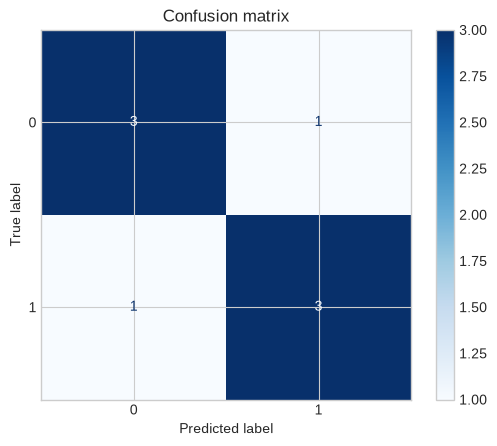

In [8]:
y_actual = np.array([1, 0, 1, 1, 0, 0, 1, 0])
y_predicted = np.array([1, 0, 0, 1, 0, 1, 1, 0])
y_probability = np.array([0.90, 0.20, 0.45, 0.80, 0.10, 0.65, 0.75, 0.30])

cm = confusion_matrix(y_actual, y_predicted, labels=[0, 1])
print("Confusion matrix (rows: actual 0, 1; columns: predicted 0, 1):")
print(cm)
print(f"TN={cm[0, 0]}, FP={cm[0, 1]}, FN={cm[1, 0]}, TP={cm[1, 1]}")
ConfusionMatrixDisplay(cm, display_labels=["0", "1"]).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix")
plt.show()

### Accuracy

Accuracy is the share of all labels that are correct. It can hide mistakes when one class is much more common.

In [9]:
accuracy = accuracy_score(y_actual, y_predicted)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.75


### Precision

Precision asks: of the cases predicted as `1`, how many really are `1`?

In [10]:
precision = precision_score(y_actual, y_predicted, zero_division=0)
print(f"Precision: {precision:.2f}")

Precision: 0.75


### Recall

Recall asks: of the real `1` cases, how many did the model find?

In [11]:
recall = recall_score(y_actual, y_predicted, zero_division=0)
print(f"Recall: {recall:.2f}")

Recall: 0.75


### F1 score

F1 gives one score that balances precision and recall. It is their harmonic mean. The slides also show that a low precision or recall can make F1 low.

In [12]:
f1 = f1_score(y_actual, y_predicted, zero_division=0)
print(f"F1: {f1:.2f}")

F1: 0.75


### ROC curve and AUC

The ROC curve shows true positive rate against false positive rate at many probability cutoffs. AUC summarizes this curve. A larger AUC is usually better. It needs both classes in the actual values.

AUC: 0.94


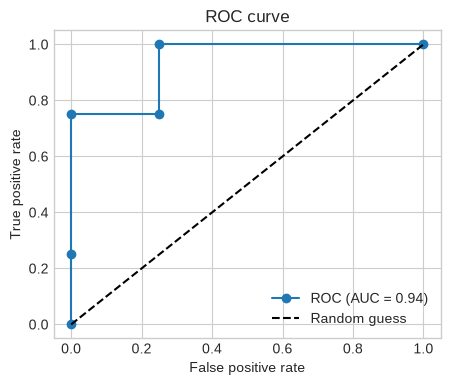

In [13]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_actual, y_probability)
auc = roc_auc_score(y_actual, y_probability)
print(f"AUC: {auc:.2f}")
plt.figure(figsize=(5, 4))
plt.plot(false_positive_rate, true_positive_rate, marker="o", label=f"ROC (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

### Interactive classification

Edit the comma-separated actual labels, predicted labels, and probability scores. The confusion matrix and scores update. Keep the lists the same length. Actual labels must include both `0` and `1` for ROC/AUC.

In [14]:
actual_text = widgets.Text(value="1,0,1,1,0,0,1,0", description="Actual", layout=widgets.Layout(width="600px"))
pred_text = widgets.Text(value="1,0,0,1,0,1,1,0", description="Predicted", layout=widgets.Layout(width="600px"))
prob_text = widgets.Text(value="0.90,0.20,0.45,0.80,0.10,0.65,0.75,0.30", description="Probability", layout=widgets.Layout(width="600px"))
class_output = widgets.Output()

def parse_values(text):
    return np.array([float(value.strip()) for value in text.split(",") if value.strip()])

def update_classification(change=None):
    with class_output:
        class_output.clear_output(wait=True)
        try:
            actual = parse_values(actual_text.value).astype(int)
            predicted = parse_values(pred_text.value).astype(int)
            probability = parse_values(prob_text.value)
            if len(actual) == 0 or len(actual) != len(predicted) or len(actual) != len(probability):
                raise ValueError("Enter the same number of values in all three boxes.")
            if not np.isin(actual, [0, 1]).all() or not np.isin(predicted, [0, 1]).all():
                raise ValueError("Actual and predicted labels must be 0 or 1.")
            if ((probability < 0) | (probability > 1)).any():
                raise ValueError("Probabilities must be between 0 and 1.")
            cm_now = confusion_matrix(actual, predicted, labels=[0, 1])
            print(f"Accuracy: {accuracy_score(actual, predicted):.2f}   Precision: {precision_score(actual, predicted, zero_division=0):.2f}   Recall: {recall_score(actual, predicted, zero_division=0):.2f}   F1: {f1_score(actual, predicted, zero_division=0):.2f}")
            fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
            ConfusionMatrixDisplay(cm_now, display_labels=["0", "1"]).plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
            axes[0].set_title("Confusion matrix")
            if len(np.unique(actual)) == 2:
                fpr, tpr, _ = roc_curve(actual, probability)
                auc_value = roc_auc_score(actual, probability)
                axes[1].plot(fpr, tpr, marker="o", label=f"ROC (AUC = {auc_value:.2f})")
                axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
                axes[1].legend()
                axes[1].set_title("ROC curve")
            else:
                axes[1].text(0.5, 0.5, "ROC/AUC needs both actual classes", ha="center", va="center")
                axes[1].set_title("ROC curve")
            axes[1].set(xlabel="False positive rate", ylabel="True positive rate")
            plt.tight_layout()
            plt.show()
        except Exception as error:
            print(f"Please check the values: {error}")

for box in [actual_text, pred_text, prob_text]:
    box.observe(update_classification, names="value")
display(widgets.VBox([actual_text, pred_text, prob_text, class_output]))
update_classification()

## Part 4 — Quick Comparison

| Problem | Metric | What it measures |
| --- | --- | --- |
| Regression | MSE | Average squared error |
| Regression | MAE | Average absolute error |
| Regression | RMSE | Typical error size, in the target units |
| Regression | R² | Fit compared with guessing the actual average |
| Classification | Accuracy | Share of all labels that are correct |
| Classification | Precision | How often predicted positives are correct |
| Classification | Recall | How many real positives are found |
| Classification | F1 | Balance of precision and recall |
| Classification | AUC | How well scores separate the two classes |